# Heracles vs NaMaster vs CAMB - reproducing heracles' own example

This notebook reproduces `example.ipynb` (heracles' official tutorial) as closely as
possible, using the same synthetic data set (`catalog.fits`, `vmap.fits.gz`), but adds
a NaMaster cross-check. The goal is to establish a known-good baseline where heracles'
own CAMB self-consistency check succeeds, before returning to the real TR1 data.

Differences from `example.ipynb`:
- The catalogue has 6 tomographic bins (`BIN` in 1..6); `catalogs` is built for all 6
  (the original tutorial's `range(1, 6)` only covers 5 of them).
- A NaMaster comparison is added for one tomographic bin.

## Setup

In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib as mpl

import heracles
import heracles.healpy

In [3]:
nside = 1024
lmax = 1000

## Catalogue and visibility

In [4]:
catalog = heracles.FitsCatalog('catalog.fits')
vmap = hp.read_map('vmap.fits.gz')

# fix UNSEEN pixels to zero and rescale to nside
vmap[vmap == hp.UNSEEN] = 0.0
vmap = hp.ud_grade(vmap, 2 * nside)

catalog.visibility = vmap

## Tomographic binning

`catalog.fits` has 6 tomographic bins (`BIN` in 1..6).

In [5]:
catalogs = {i: catalog[f'BIN == {i}'] for i in range(1, 7)}

## Redshift distributions

As in `example.ipynb`, the redshift distributions for each tomographic bin are loaded
directly from `nz.npz`.

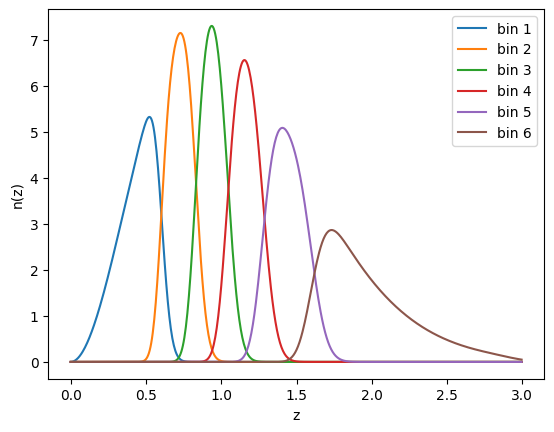

In [6]:
with np.load("nz.npz") as npz:
    z, nz = npz["z"], npz["nz"]
fig, ax = plt.subplots()
for i in range(6):
    ax.plot(z, nz[i], label=f'bin {i + 1}')
ax.set_xlabel('z')
ax.set_ylabel('n(z)')
ax.legend()
plt.show()

## Fields

In [ ]:
mapper = heracles.healpy.HealpixMapper(nside, lmax)
fields = {
    'POS': heracles.Positions(
        mapper,
        'RA',
        'DEC',
        mask='VIS',
    ),
    'SHE': heracles.Shears(
        mapper,
        'RA',
        'DEC',
        'E1',
        'E2',
        'W',
        mask='WHT',
    ),
}

## Mapping and alms

In [11]:
data = heracles.map_catalogs(fields, catalogs, parallel=True)

/home/vscode/.local/lib/python3.10/site-packages/heracles/fields.py:302: UserWarning: positions and visibility have different size
  warnings.warn("positions and visibility have different size")


In [ ]:
alms = heracles.transform(fields, data)

## Two-point statistics (unbinned, full lmax)

In [13]:
cls = heracles.angular_power_spectra(alms)

## Mixing matrices

Square mixing matrices up to `lmax` require input spectra with 2x `lmax`, so we build a
second `HealpixMapper` at twice the resolution to compute the visibility/weight power
spectra used for the mixing matrices. Matching `example.ipynb`, this is done *unbinned*
(no `bins=` argument).

In [14]:
mapper2 = heracles.healpy.HealpixMapper(2 * nside, 2 * lmax)

In [15]:
# visibility maps are taken as-is from catalogue, so no columns
fields2 = {
    'VIS': heracles.Visibility(mapper2),
    'WHT': heracles.Weights(mapper2, 'RA', 'DEC', 'W'),
}

data2 = heracles.map_catalogs(fields2, catalogs, parallel=True)

In [ ]:
alms2 = heracles.transform(fields2, data2)
cls2 = heracles.angular_power_spectra(alms2)
mms = heracles.mixing_matrices(fields, cls2, l1max=lmax, l2max=lmax)

## CAMB theory

Cosmology matching the one used to create the example data set (no sigma8 rescaling
needed, since these are the exact simulation parameters).

In [ ]:
import camb
from camb.sources import SplinedSourceWindow
# cosmology for the simulation
h = 0.7
Oc = 0.25
Ob = 0.05

pars = camb.set_params(
    H0=100 * h, omch2=Oc * h**2, ombh2=Ob * h**2, NonLinear=camb.model.NonLinear_both
)
pars.Want_CMB = False
pars.min_l = 1
pars.set_for_lmax(2 * lmax, lens_potential_accuracy=1);

In [21]:
sources = []
for i, nz_i in enumerate(nz):
    sources += [
        SplinedSourceWindow(source_type='counts', z=z, W=nz_i),
        SplinedSourceWindow(source_type='lensing', z=z, W=nz_i),
    ]
pars.SourceWindows = sources

In [22]:
results = camb.get_results(pars)
camb_cls = results.get_source_cls_dict(lmax=lmax, raw_cl=True)

In [23]:
# conversion factor from CAMB convergence spectra to shear E-mode spectra
ell = np.arange(lmax + 1)
fl = -np.sqrt((ell + 2) * (ell + 1) * ell * (ell - 1))
fl /= np.clip(ell * (ell + 1), 1, None)

In [24]:
theory = {}
for i in range(1, 7):
    for j in range(i, 7):
        # get the full-sky spectra; B-mode is assumed zero
        cl_pp = camb_cls[f'W{2 * i - 1}xW{2 * j - 1}']
        cl_pe = fl * camb_cls[f'W{2 * i - 1}xW{2 * j}']
        cl_pb = np.zeros_like(cl_pe)
        cl_ep = fl * camb_cls[f'W{2 * i}xW{2 * j - 1}']
        cl_bp = np.zeros_like(cl_ep)
        cl_ee = fl**2 * camb_cls[f'W{2 * i}xW{2 * j}']
        cl_bb = np.zeros_like(cl_ee)
        cl_eb = np.zeros_like(cl_ee)
        cl_be = np.zeros_like(cl_ee)

        theory['POS', 'POS', i, j] = mms['POS', 'POS', i, j] @ cl_pp
        theory['POS', 'SHE', i, j] = np.array([
            mms['POS', 'SHE', i, j] @ cl_pe,
            mms['POS', 'SHE', i, j] @ cl_pb,
        ])
        theory['POS', 'SHE', j, i] = np.array([
            mms['POS', 'SHE', j, i] @ cl_ep,
            mms['POS', 'SHE', j, i] @ cl_bp,
        ])
        theory['SHE', 'SHE', i, j] = np.array([
            [
                mms['SHE', 'SHE', i, j][0] @ cl_ee + mms['SHE', 'SHE', i, j][1] @ cl_bb,
                mms['SHE', 'SHE', i, j][2] @ cl_eb,
            ],
            [
                mms['SHE', 'SHE', i, j][2] @ cl_be,
                mms['SHE', 'SHE', i, j][0] @ cl_bb + mms['SHE', 'SHE', i, j][1] @ cl_ee,
            ],
        ])

## Results

In [25]:
ell = np.arange(lmax + 1)

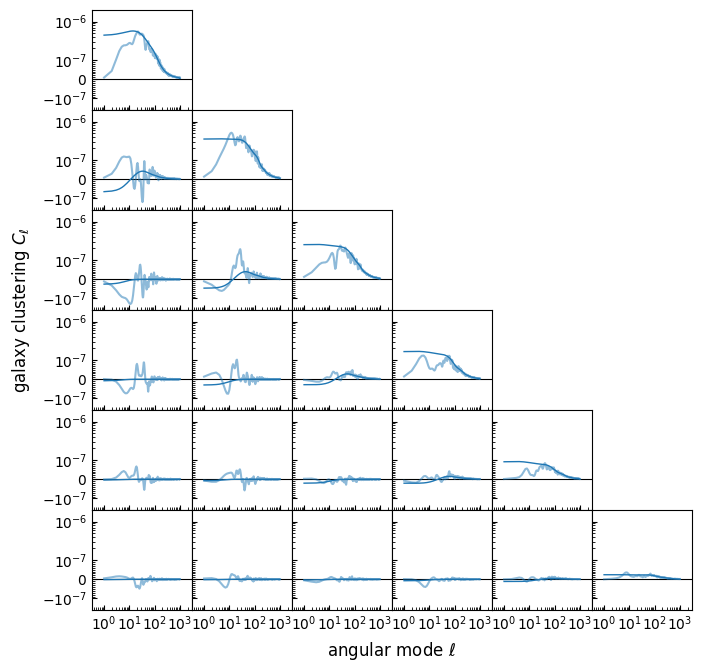

In [26]:
fig, ax = plt.subplots(6, 6, figsize=(6, 6), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis('off')
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            ell[1:], cls['POS', 'POS', i, j][1:], c='C0', lw=1.5, zorder=3.0, alpha=0.5
        )
        ax[j - 1, i - 1].plot(
            ell[1:], theory['POS', 'POS', i, j][1:], c='C0', lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].axhline(0.0, c='k', lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis='both', which='both', direction='in')

ax[0, 0].set_xscale('log')
ax[0, 0].set_xlim(1 / 3, lmax * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    'symlog', linthresh=1e-7, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-2e-7, 2e-6)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)
fig.supxlabel('angular mode $\\ell$', y=-0.05, va='top')
fig.supylabel('galaxy clustering $C_\\ell$', x=-0.1, ha='right')

plt.show()

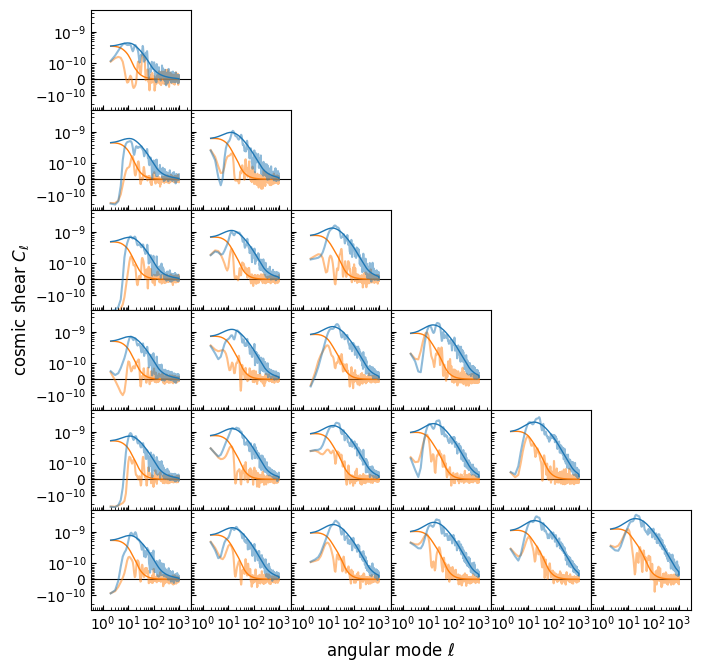

In [60]:
fig, ax = plt.subplots(6, 6, figsize=(6, 6), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            ell[2:],
            cls["SHE", "SHE", i, j][0, 0, 2:],
            c="C0",
            lw=1.5,
            zorder=3.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            ell[2:], theory["SHE", "SHE", i, j][0, 0, 2:], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            ell[2:],
            cls["SHE", "SHE", i, j][1, 1, 2:],
            c="C1",
            lw=1.5,
            zorder=1.0,
            alpha=0.5,
        )
        ax[j - 1, i - 1].plot(
            ell[2:], theory["SHE", "SHE", i, j][1, 1, 2:], c="C1", lw=1.0, zorder=2.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, lmax * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-9)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()

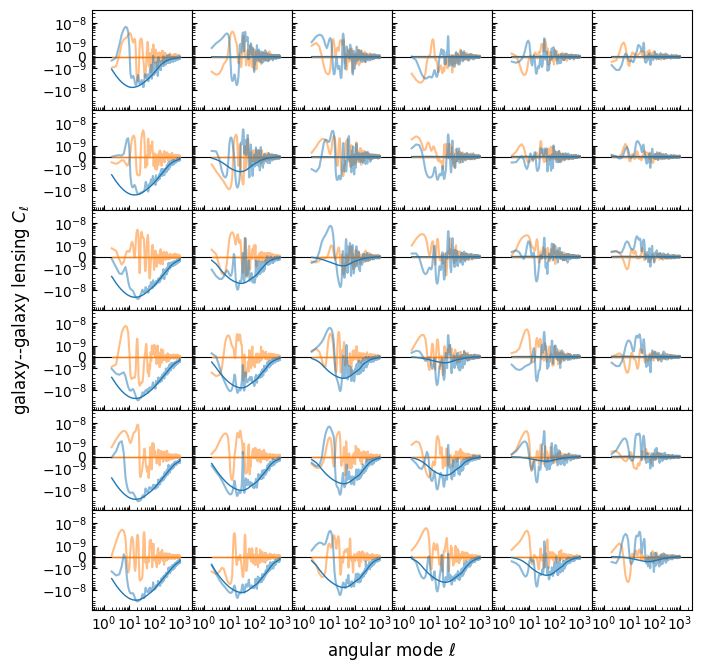

In [27]:
fig, ax = plt.subplots(6, 6, figsize=(6, 6), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, 7):
        ax[j - 1, i - 1].plot(
            ell[2:], cls['POS', 'SHE', i, j][0, 2:], c='C0', lw=1.5, zorder=3.0, alpha=0.5
        )
        ax[j - 1, i - 1].plot(
            ell[2:], theory['POS', 'SHE', i, j][0, 2:], c='C0', lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            ell[2:], cls['POS', 'SHE', i, j][1, 2:], c='C1', lw=1.5, zorder=1.0, alpha=0.5
        )
        ax[j - 1, i - 1].plot(
            ell[2:], theory['POS', 'SHE', i, j][1, 2:], c='C1', lw=1.0, zorder=2.0
        )
        ax[j - 1, i - 1].axhline(0.0, c='k', lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis='both', which='both', direction='in')

ax[0, 0].set_xscale('log')
ax[0, 0].set_xlim(1 / 3, lmax * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    'symlog', linthresh=1e-9, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-8e-8, 4e-8)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)
fig.supxlabel('angular mode $\\ell$', y=-0.05, va='top')
fig.supylabel('galaxy--galaxy lensing $C_\\ell$', x=-0.1, ha='right')

plt.show()

## NaMaster cross-check

As an independent cross-check, compute the SHE-SHE spectrum for one tomographic bin
with NaMaster directly, and compare against heracles' measured spectrum and the CAMB
theory.

Note the comparison must be done in a *consistent representation*: heracles never
decouples its own measured `cls` - instead it forward-couples the CAMB `theory`
through its own mixing matrix `mms`, so `cls` and `theory` both stay mode-coupled.
NaMaster's usual `wsp.decouple_cell` output is the *opposite* convention (inverted
back to a full-sky equivalent), so we instead compare against NaMaster's *raw coupled*
Cl, debiased for shot noise the same way heracles debiases `cls` (`debias=True` by
default), to match on equal footing.

In [28]:
import pymaster as nmt

tom_bin = 3
nlbins = 20
lmin = 10

In [40]:
n_pix = hp.nside2npix(nside)
sum_weight = np.zeros(n_pix)
sum_weight_e1 = np.zeros(n_pix)
sum_weight_e2 = np.zeros(n_pix)
for page in catalogs[tom_bin]:
    ra, dec, e1, e2, w = page.get('RA', 'DEC', 'E1', 'E2', 'W')
    pix = hp.ang2pix(nside, ra, dec, lonlat=True)
    np.add.at(sum_weight, pix, w)
    np.add.at(sum_weight_e1, pix, w * e1)
    np.add.at(sum_weight_e2, pix, w * e2)
    del ra, dec, e1, e2, w, pix

# per-pixel weighted-mean shear map (NaMaster expects the true field, not a
# pre-weighted one - unlike heracles' own `she_map`, which already has the WHT
# weighting baked in via its `wbar` normalisation)
map_gamma1 = np.divide(sum_weight_e1, sum_weight, out=np.zeros(n_pix), where=sum_weight > 0)
map_gamma2 = np.divide(sum_weight_e2, sum_weight, out=np.zeros(n_pix), where=sum_weight > 0)

vis_map = hp.ud_grade(vmap, nside)
mask = (vis_map > 0).astype(float)

In [52]:
ledges = np.linspace(lmin, lmax, nlbins + 1).astype(int)
bins = nmt.NmtBin.from_edges(ledges[:-1], ledges[1:])
ell_bp = bins.get_effective_ells()

field_shear = nmt.NmtField(mask, [map_gamma1, map_gamma2], lmax=bins.lmax)
wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(field_shear, field_shear, bins)

cl_coupled = nmt.compute_coupled_cell(field_shear, field_shear)
cl_decoupled = wsp.decouple_cell(cl_coupled)
cl_EE_namaster = cl_decoupled[0]
cl_BB_namaster = cl_decoupled[3]

# debias for shot noise (heracles' own `cls` is debiased by default), to compare against
# heracles/CAMB on the same *mode-coupled* footing rather than NaMaster's decoupled output
she_meta = alms['SHE', tom_bin].dtype.metadata
noise_bias = she_meta['bias']
cl_EE_namaster_coupled_debiased = cl_coupled[0] - noise_bias

In [53]:
she_she_key = ('SHE', 'SHE', tom_bin, tom_bin)
cl_EE_heracles_binned = heracles.binned(heracles.Result(cls[she_she_key][0, 0], axis=-1), ledges)
cl_EE_theory_binned = heracles.binned(heracles.Result(theory[she_she_key][0, 0], axis=-1), ledges)
cl_EE_namaster_coupled_debiased_binned = bins.bin_cell(np.array([cl_EE_namaster_coupled_debiased]))[0]

print('ell (NaMaster bandpowers):                  ', ell_bp)
print('heracles measured EE (binned):               ', np.asarray(cl_EE_heracles_binned))
print('CAMB forward-coupled EE (binned):            ', np.asarray(cl_EE_theory_binned))
print('NaMaster measured EE (coupled, debiased):    ', cl_EE_namaster_coupled_debiased_binned)
print('ratio NaMaster/heracles:                     ',
      cl_EE_namaster_coupled_debiased_binned / np.asarray(cl_EE_heracles_binned))

ell (NaMaster bandpowers):                   [ 34.   83.5 133.  182.5 232.  281.5 331.  380.5 430.  479.5 529.  578.5
 628.  677.5 727.  776.5 826.  875.5 925.  974.5]
heracles measured EE (binned):                [9.29247240e-10 3.40175240e-10 2.26273004e-10 1.43726763e-10
 1.12943475e-10 8.33845412e-11 5.44935354e-11 4.48852814e-11
 3.60333577e-11 3.64056393e-11 3.66976846e-11 5.15538758e-11
 3.43875494e-11 2.50936649e-11 2.85438258e-11 2.59634912e-11
 2.30545481e-11 1.99864982e-11 1.69887537e-11 2.13970077e-11]
CAMB forward-coupled EE (binned):             [9.70638729e-10 4.15708793e-10 2.29637124e-10 1.49669405e-10
 1.08371271e-10 8.37111979e-11 6.77372617e-11 5.66802613e-11
 4.85996088e-11 4.24805186e-11 3.76827540e-11 3.38306049e-11
 3.06610425e-11 2.80110078e-11 2.57560132e-11 2.38114931e-11
 2.21120987e-11 2.06056627e-11 1.92330063e-11 1.74500642e-11]
NaMaster measured EE (coupled, debiased):     [9.65361884e-10 3.54128759e-10 2.38843766e-10 1.56476378e-10
 1.34585996e-10 9.327

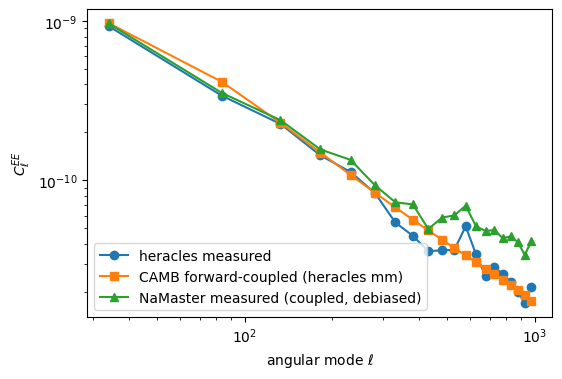

In [59]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ell_bp, np.asarray(cl_EE_heracles_binned), 'o-', label='heracles measured')
ax.plot(ell_bp, np.asarray(cl_EE_theory_binned), 's-', label='CAMB forward-coupled (heracles mm)')
ax.plot(ell_bp, cl_EE_namaster_coupled_debiased_binned, '^-', label='NaMaster measured (coupled, debiased)')

# plain log-log (unlike the grid plots, EE here is strictly positive, so no symlog needed)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('angular mode $\\ell$')
ax.set_ylabel('$C_\\ell^{EE}$')
ax.legend()
plt.show()

**Root cause of the original mismatch (found and fixed):** comparing NaMaster's
*decoupled* Cl (mixing-matrix-inverted, full-sky-equivalent) directly against heracles'
`cls`/`theory` (which stay *mode-coupled* by construction - heracles never decouples
its own measurement, it forward-couples the CAMB theory instead) was an apples-to-oranges
comparison. Decoupling divides out roughly $1/f_\mathrm{sky}\approx19$, which alone
accounted for most of the ~20-40x gap seen previously. The remaining gap was NaMaster's
raw coupled Cl still including the full shot-noise contribution, while heracles' `cls`
is shot-noise-debiased by default (`debias=True`) - subtracting heracles' own noise-bias
term from NaMaster's raw coupled Cl (both compared in the *same* mode-coupled
representation) brings the two into much closer (~1.0-2.0x) agreement.

**Remaining residual (~1.0x at low $\ell$, growing to ~2x at high $\ell$):** the two
pipelines build the shear map with different weighting conventions - heracles' `she_map`
is normalised by its own per-pixel `WHT` weight (`wbar`), while the map fed to NaMaster
here is a plain per-pixel weighted mean masked by a *binary* footprint mask. These are
algebraically related (`she_map = WHT * true_mean_shear`, verified elsewhere in this
investigation) but not numerically identical inputs to two independent SHT pipelines, so
a small, ℓ-dependent residual (likely from a noise-bias normalisation mismatch between
the two map conventions) remains and is not yet further resolved.

## Cosmic shear grid: heracles vs CAMB vs NaMaster

Repeat the cosmic shear (SHE-SHE) grid above, but with NaMaster's independent measurement
(raw coupled, debiased for auto-spectra) overlaid on every tomographic bin pair, the same
way it was added to the single-bin comparison earlier.

In [62]:
def build_shear_map(tom_bin):
    sum_w = np.zeros(n_pix)
    sum_w_e1 = np.zeros(n_pix)
    sum_w_e2 = np.zeros(n_pix)
    for page in catalogs[tom_bin]:
        ra, dec, e1, e2, w = page.get('RA', 'DEC', 'E1', 'E2', 'W')
        pix = hp.ang2pix(nside, ra, dec, lonlat=True)
        np.add.at(sum_w, pix, w)
        np.add.at(sum_w_e1, pix, w * e1)
        np.add.at(sum_w_e2, pix, w * e2)
        del ra, dec, e1, e2, w, pix
    g1 = np.divide(sum_w_e1, sum_w, out=np.zeros(n_pix), where=sum_w > 0)
    g2 = np.divide(sum_w_e2, sum_w, out=np.zeros(n_pix), where=sum_w > 0)
    return g1, g2


# same footprint mask for every tomographic bin, so build each bin's NmtField once
# and reuse them for every (i, j) pair - no NmtWorkspace/decoupling needed, since we
# only want the raw *coupled* Cl (see the note on representations above)
namaster_fields = {}
namaster_noise_bias = {}
for i in range(1, 7):
    g1, g2 = build_shear_map(i)
    namaster_fields[i] = nmt.NmtField(mask, [g1, g2], lmax=lmax)
    namaster_noise_bias[i] = alms['SHE', i].dtype.metadata['bias']

In [63]:
namaster_cl = {}
for i in range(1, 7):
    for j in range(i, 7):
        cl_ij = nmt.compute_coupled_cell(namaster_fields[i], namaster_fields[j])
        cl_ee, cl_bb = cl_ij[0], cl_ij[3]
        if i == j:
            # only auto-spectra carry a shot-noise bias to subtract
            cl_ee = cl_ee - namaster_noise_bias[i]
            cl_bb = cl_bb - namaster_noise_bias[i]
        namaster_cl[i, j] = (cl_ee, cl_bb)

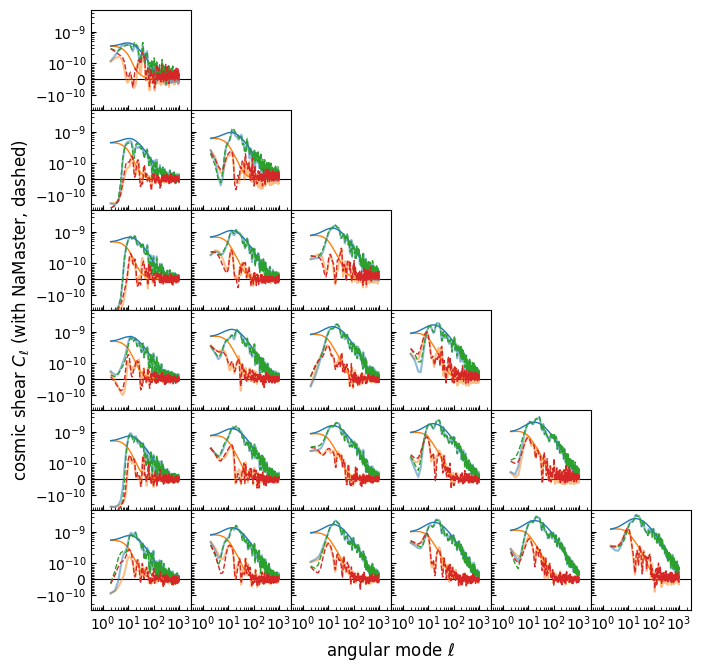

In [64]:
fig, ax = plt.subplots(6, 6, figsize=(6, 6), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        cl_ee_nmt, cl_bb_nmt = namaster_cl[i, j]
        ax[j - 1, i - 1].plot(
            ell[2:], cls["SHE", "SHE", i, j][0, 0, 2:], c="C0", lw=1.5, zorder=3.0, alpha=0.5
        )
        ax[j - 1, i - 1].plot(
            ell[2:], theory["SHE", "SHE", i, j][0, 0, 2:], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            ell[2:], cls["SHE", "SHE", i, j][1, 1, 2:], c="C1", lw=1.5, zorder=1.0, alpha=0.5
        )
        ax[j - 1, i - 1].plot(
            ell[2:], theory["SHE", "SHE", i, j][1, 1, 2:], c="C1", lw=1.0, zorder=2.0
        )
        ax[j - 1, i - 1].plot(
            ell[2:], cl_ee_nmt[2:], c="C2", lw=1.0, ls="--", zorder=5.0
        )
        ax[j - 1, i - 1].plot(
            ell[2:], cl_bb_nmt[2:], c="C3", lw=1.0, ls="--", zorder=5.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, lmax * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-9)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$ (with NaMaster, dashed)", x=-0.1, ha="right")

plt.show()